# Cetacean Detection — Model vs Expert Comparison (ARBAS)

Compares model predictions (5-second segments) against expert annotations (1-minute WAV files), aggregated to **5-minute interval level** to match the Harrapatu blueprint.

### Key differences from the Harrapatu notebook
- **Expert format**: two XLSX sheets (May / August) with per-WAV PAMGuard vote counts for **multiple species**. All intervals where total expert votes > 0 are expert-positive. Intervals with zero votes are expert-negative.
- **Join key**: matching on the **5-minute interval** derived from the WAV filename timestamp (`YYMMDDHHMMSS`, truncated to the nearest 5 min), same as Harrapatu.
- **Multi-species**: the expert annotated multiple species (Dd, Gg, Gm, Oo, Pm, Sc, Tt, Ambig + expert-only: Bb, Dc, Lo, Zc). Main evaluation is **cetacean-in-general** (any species vs background). Per-species breakdown is in cells C/D.
- **Resolution mismatch**: expert labels are per 1-min WAV → we aggregate model 5-s segments up to the 5-min interval before scoring.

### Three prediction strategies (same MLP, different post-hoc decoding)
| Strategy | How it decides |
|---|---|
| `argmax` | plain softmax argmax |
| `vec` | per-class `w·logit + b`, inv-freq weighted |
| `pr` | argmax among species clearing F1-optimal threshold, else background |

### Consensus (`pred_consensus`)
All three agree → that label; else `'uncertain'` (treated as non-detection).

### Sub-segment FN logic
For an expert-positive interval, **one firing segment is enough** to catch the signal.  
Non-firing segments inside a caught (TP) interval are TN — no need for signal in the whole area.


In [1]:
# ── 0. Imports & paths ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── EDIT THESE ───────────────────────────────────────────────────────────────
MY_PREDICTIONS_CSV = r"/data2/mromaniuc/cet-det/inference/inference_arbas/predictions/arbas_predictions_l4.csv"
EXPERT_MAY_XLSX    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/comparison/expert_validated_data/XIULOS_MAIG_TOTAL.xlsx"
EXPERT_AUG_XLSX    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/comparison/expert_validated_data/XiulosAGOST_TOTAL.xlsx"
SPECTROGRAM_DIR    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/spectrograms/spectrograms"
OUTPUT_CSV         = "arbas_comparison_5min_v1.csv"

EXPERT_MAY_SHEET   = 'in'
EXPERT_AUG_SHEET   = 'XiulosAGOST_TOTAL'
# ─────────────────────────────────────────────────────────────────────────────

def normalise_wav_name(x):
    """Return just 'XXXX.wav' from any path, Windows or POSIX, with cleanup."""
    if pd.isna(x):
        return None
    s = str(x).strip().strip('"').strip("'")
    s = s.replace('\\\\', '/').replace('\\', '/')
    s = s.split('/')[-1]
    s = s.strip().lower()
    if not s.endswith('.wav'):
        s = s + '.wav'
    return s

def interval_from_wav(wav_name):
    """Extract YYMMDDHHMMSS timestamp and floor to nearest 5-min interval.

    '6338.240528160459.wav' -> '240528160000'  (floor to HH MM00, nearest 5 min)
    Works on raw paths too (normalise_wav_name applied first).
    """
    if pd.isna(wav_name):
        return None
    base = normalise_wav_name(wav_name)
    parts = base.split('.')
    if len(parts) < 2:
        return None
    ts = parts[1]   # YYMMDDHHMMSS, 12 chars
    if len(ts) != 12 or not ts.isdigit():
        return None
    # floor minutes to nearest 5
    mm = int(ts[8:10])
    mm5 = (mm // 5) * 5
    return ts[:8] + f"{mm5:02d}" + "00"

print("Config loaded.  Self-test of interval_from_wav:")
for t in [r'D:\\IM-23-ARBAS\\Soundtrap 6338\\6338.240528160459.wav',
          '6338.240528160459.wav', '6312.240806141558.wav',
          '6338.240528160000.wav']:
    print(f"  {t!r:70s} -> {interval_from_wav(t)!r}")


Config loaded.  Self-test of interval_from_wav:
  'D:\\\\IM-23-ARBAS\\\\Soundtrap 6338\\\\6338.240528160459.wav'         -> '240528160000'
  '6338.240528160459.wav'                                                -> '240528160000'
  '6312.240806141558.wav'                                                -> '240806141500'
  '6338.240528160000.wav'                                                -> '240528160000'


In [2]:
# ── 1. Load model predictions ────────────────────────────────────────────────
df_mine = pd.read_csv(MY_PREDICTIONS_CSV)
print(f"Raw CSV: {len(df_mine):,} rows, {df_mine.shape[1]} columns")

PATH_COL = next((c for c in ['wav_path', 'wav_name', 'file', 'filename', 'path']
                 if c in df_mine.columns), None)
assert PATH_COL is not None, f"No path column found. Columns: {list(df_mine.columns)}"
print(f"Using '{PATH_COL}' as the wav path column.")

df_mine['wav_name'] = df_mine[PATH_COL].apply(normalise_wav_name)
df_mine['interval'] = df_mine['wav_name'].map(interval_from_wav)
print(f"Example wav_name: {df_mine['wav_name'].iloc[0]!r}  interval: {df_mine['interval'].iloc[0]!r}")

# Rename prob columns to short codes
PROB_RENAME = {
    'prob_Balaenoptera_acutorostrata': 'prob_Ba',
    'prob_Balaenoptera_physalus':      'prob_Bp',
    'prob_Delphinidae_unknown':        'prob_Ambig',
    'prob_Delphinus_delphis':          'prob_Dd',
    'prob_Globicephala_melas':         'prob_Gm',
    'prob_Grampus_griseus':            'prob_Gg',
    'prob_Orcinus_orca':               'prob_Oo',
    'prob_Physeter_macrocephalus':     'prob_Pm',
    'prob_Stenella_coeruleoalba':      'prob_Sc',
    'prob_Tursiops_truncatus':         'prob_Tt',
    'prob_background':                 'prob_bg',
}
df_mine.rename(columns=PROB_RENAME, inplace=True)

CETACEAN_PROB_COLS = ['prob_Ba','prob_Bp','prob_Ambig','prob_Dd','prob_Gm',
                      'prob_Gg','prob_Oo','prob_Pm','prob_Sc','prob_Tt']
missing_probs = [c for c in CETACEAN_PROB_COLS + ['prob_bg'] if c not in df_mine.columns]
assert not missing_probs, f"Missing probability columns after rename: {missing_probs}"

STRAT_COLS = ['pred_argmax', 'pred_vec', 'pred_pr']
for col in STRAT_COLS:
    assert col in df_mine.columns, f"Strategy column '{col}' not in CSV."
    df_mine[col] = df_mine[col].astype(str).str.strip()

# Guard against duplicate (wav_name, segment_index)
if 'segment_index' in df_mine.columns:
    seg_dups = df_mine.duplicated(subset=['wav_name', 'segment_index']).sum()
    if seg_dups:
        print(f"  ⚠ {seg_dups} duplicate (wav_name, segment_index) — keeping first.")
        df_mine = df_mine.drop_duplicates(subset=['wav_name', 'segment_index'],
                                          keep='first').reset_index(drop=True)

# Consensus: all three agree → that label; else 'uncertain'
def make_consensus(row):
    labels = {row['pred_argmax'], row['pred_vec'], row['pred_pr']}
    return row['pred_argmax'] if len(labels) == 1 else 'uncertain'
df_mine['pred_consensus'] = df_mine.apply(make_consensus, axis=1)

# Detection flags per strategy
for s in ['argmax', 'vec', 'pr', 'consensus']:
    df_mine[f'cetacean_{s}'] = df_mine[f'pred_{s}'] != 'background'
df_mine.loc[df_mine['pred_consensus'] == 'uncertain', 'cetacean_consensus'] = False

df_mine['max_cetacean_prob'] = df_mine[CETACEAN_PROB_COLS].max(axis=1)

print(f"\nLoaded {len(df_mine):,} segments from {df_mine['wav_name'].nunique():,} WAV files "
      f"across {df_mine['interval'].nunique():,} unique 5-min intervals")
for s in ['argmax', 'vec', 'pr', 'consensus']:
    n = df_mine[f'cetacean_{s}'].sum()
    print(f"  {s:10s}: {n:,} cetacean segments ({100*n/len(df_mine):.1f}%)")
print(f"  {'uncertain':10s}: {(df_mine['pred_consensus']=='uncertain').sum():,}")

df_mine[['wav_name','interval','segment_index','offset_s',
         'pred_argmax','pred_vec','pred_pr','pred_consensus']].head(5)


Raw CSV: 117,650 rows, 23 columns
Using 'wav_path' as the wav path column.
Example wav_name: '6338.240528160459.wav'  interval: '240528160000'

Loaded 117,650 segments from 9,805 WAV files across 1,963 unique 5-min intervals
  argmax    : 37,916 cetacean segments (32.2%)
  vec       : 57,351 cetacean segments (48.7%)
  pr        : 18,349 cetacean segments (15.6%)
  consensus : 18,348 cetacean segments (15.6%)
  uncertain : 39,189


,wav_name,interval,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus
0,6338.240528160459.wav,240528160000,0,0.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
1,6338.240528160459.wav,240528160000,1,5.0,Delphinidae_unknown,Delphinidae_unknown,background,uncertain
2,6338.240528160459.wav,240528160000,2,10.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
3,6338.240528160459.wav,240528160000,3,15.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
4,6338.240528160459.wav,240528160000,4,20.0,background,Delphinidae_unknown,background,uncertain


In [3]:
# ── 2. Load expert annotations ───────────────────────────────────────────────
# Two XLSX sheets (May / August) with PAMGuard vote counts per 1-min WAV.
# We aggregate votes → interval-level expert label (any species, any hydrophone).

EXPERT_VOTE_RENAME = {
    'Ambig_votes': 'exp_Ambig',
    'Bb_votes':    'exp_Bb',   # expert-only species (not in model vocab)
    'Dc_votes':    'exp_Dc',
    'Dd_votes':    'exp_Dd',
    'Gg_votes':    'exp_Gg',
    'Gm_votes':    'exp_Gm',
    'Lo_votes':    'exp_Lo',
    'Oo_votes':    'exp_Oo',
    'Pm_votes':    'exp_Pm',
    'Sc_votes':    'exp_Sc',
    'Tt_votes':    'exp_Tt',
    'Zc_votes':    'exp_Zc',
}
EXP_VOTE_COLS = list(EXPERT_VOTE_RENAME.values())

# PAMGuard vote cells may be inflated by power-of-10 locale artefact — recover them.
VOTE_MAX = 10.0

def recover_vote(x):
    if pd.isna(x):
        return 0.0
    try:
        f = float(str(x).strip().strip('"').strip("'").replace(',', '.'))
    except (ValueError, TypeError):
        return 0.0
    if f == 0.0:
        return 0.0
    sign = -1.0 if f < 0 else 1.0
    f = abs(f)
    while f >= VOTE_MAX:
        f /= 10.0
    return sign * f

def clean_vote_series(s):
    raw = pd.to_numeric(s.astype(str).str.strip().str.replace(',', '.', regex=False),
                        errors='coerce')
    n_inflated = int((raw.abs() >= VOTE_MAX).sum())
    out = s.apply(recover_vote)
    return out, n_inflated

def load_expert_sheet(path, sheet_name):
    df = pd.read_excel(path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]

    fname_col = next((c for c in df.columns
                      if c.strip().upper() in ('ARXIU', 'FILENAME', 'WAV', 'FILE')), None)
    if fname_col is None:
        raise ValueError(f"No filename column in {Path(path).name}/{sheet_name}. "
                         f"Columns: {list(df.columns)}")
    df.rename(columns={fname_col: 'wav_name_raw'}, inplace=True)
    df['wav_name'] = df['wav_name_raw'].apply(normalise_wav_name)
    df['interval'] = df['wav_name'].map(interval_from_wav)

    df.rename(columns=EXPERT_VOTE_RENAME, inplace=True)
    audit = {}
    for col in EXP_VOTE_COLS:
        if col in df.columns:
            df[col], n_inflated = clean_vote_series(df[col])
            if n_inflated:
                audit[col] = n_inflated
        else:
            df[col] = 0.0

    if audit:
        total = sum(audit.values())
        print(f"  {Path(path).name}: recovered {total} inflated vote cell(s): " +
              ", ".join(f"{k.replace('exp_','')}={v}" for k, v in sorted(audit.items())))

    df['source'] = Path(path).stem
    df = df[df['wav_name'].notna() & df['interval'].notna()].copy()
    df['exp_cetacean_detected'] = df[EXP_VOTE_COLS].sum(axis=1) > 0

    # Top species by vote count (idxmax, first-wins on ties)
    vote_mat = df[EXP_VOTE_COLS]
    row_max = vote_mat.max(axis=1)
    n_ties = ((vote_mat.eq(row_max, axis=0).sum(axis=1) > 1)
              & df['exp_cetacean_detected']).sum()
    if n_ties:
        print(f"  ⚠ {Path(path).name}/{sheet_name}: {n_ties} row(s) have a top-species tie.")

    df['exp_top_species'] = vote_mat.idxmax(axis=1).str.replace('exp_', '')
    df.loc[~df['exp_cetacean_detected'], 'exp_top_species'] = 'background'
    return df

df_exp_may = load_expert_sheet(EXPERT_MAY_XLSX, EXPERT_MAY_SHEET)
df_exp_aug = load_expert_sheet(EXPERT_AUG_XLSX, EXPERT_AUG_SHEET)

print(f"\nMay   : {len(df_exp_may):,} WAVs  ({df_exp_may['exp_cetacean_detected'].sum()} cetacean)")
print(f"August: {len(df_exp_aug):,} WAVs  ({df_exp_aug['exp_cetacean_detected'].sum()} cetacean)")

df_exp_all = pd.concat([df_exp_may, df_exp_aug], ignore_index=True)
dups = df_exp_all['wav_name'].duplicated().sum()
if dups:
    print(f"  ⚠ {dups} duplicate wav_name(s) across sheets — keeping first.")
    df_exp_all = df_exp_all.drop_duplicates(subset='wav_name', keep='first')

# ── Aggregate WAV-level expert votes → interval level ────────────────────────
# An interval is expert-positive if ANY 1-min WAV in it was positive.
# Sum votes across all WAVs in the interval so we know the dominant species.
def agg_expert_interval(grp):
    exp_pos = grp['exp_cetacean_detected'].any()
    vote_sum = grp[EXP_VOTE_COLS].sum()
    top_sp = vote_sum.idxmax().replace('exp_', '') if exp_pos else 'background'
    return pd.Series({
        'exp_positive':    exp_pos,
        'exp_top_species': top_sp,
        'n_wavs_annotated': len(grp),
        'source':          ', '.join(sorted(grp['source'].unique())),
        **{f'sum_{c}': vote_sum[c] for c in EXP_VOTE_COLS},
    })

df_expert = (
    df_exp_all.groupby('interval', sort=False)
    .apply(agg_expert_interval, include_groups=False)
    .reset_index()
)
print(f"\nUnique expert-annotated 5-min intervals: {len(df_expert):,}")
print(f"  Expert-positive: {df_expert['exp_positive'].sum():,}")
print(f"  Expert-negative: {(~df_expert['exp_positive']).sum():,}")
df_expert[['interval','exp_positive','exp_top_species','n_wavs_annotated','source']].head()


  XIULOS_MAIG_TOTAL.xlsx: recovered 191 inflated vote cell(s): Dc=35, Dd=26, Gg=75, Lo=7, Oo=1, Sc=13, Tt=34
  XiulosAGOST_TOTAL.xlsx: recovered 2545 inflated vote cell(s): Dc=412, Dd=196, Gg=933, Lo=46, Oo=8, Sc=255, Tt=695
  ⚠ XiulosAGOST_TOTAL.xlsx/XiulosAGOST_TOTAL: 2 row(s) have a top-species tie.

May   : 4,062 WAVs  (115 cetacean)
August: 4,005 WAVs  (1704 cetacean)

Unique expert-annotated 5-min intervals: 1,616
  Expert-positive: 542
  Expert-negative: 1,074


,interval,exp_positive,exp_top_species,n_wavs_annotated,source
0,240528160000,False,background,1,XIULOS_MAIG_TOTAL
1,240528160500,True,Gg,5,XIULOS_MAIG_TOTAL
2,240528161000,False,background,5,XIULOS_MAIG_TOTAL
3,240528161500,False,background,5,XIULOS_MAIG_TOTAL
4,240528162000,False,background,5,XIULOS_MAIG_TOTAL


In [4]:
# ── 2b. Key-overlap diagnostic ────────────────────────────────────────────────
mine_intervals = set(df_mine['interval'].dropna().unique())
exp_intervals  = set(df_expert['interval'].dropna().unique())
exp_pos_intervals = set(df_expert.loc[df_expert['exp_positive'], 'interval'].dropna().unique())

overlap      = mine_intervals & exp_intervals
only_expert  = exp_intervals  - mine_intervals
only_model   = mine_intervals - exp_intervals

print(f"Model intervals              : {len(mine_intervals):,}")
print(f"Expert-annotated intervals   : {len(exp_intervals):,}")
print(f"  Expert-positive            : {len(exp_pos_intervals):,}")
print(f"  Expert-negative            : {len(exp_intervals) - len(exp_pos_intervals):,}")
print(f"Overlap (model saw + expert annotated): {len(overlap):,}")
print(f"Expert-annotated NOT in model         : {len(only_expert):,}")
print(f"  → these cannot be evaluated (model never processed them)")
print(f"Model intervals with no expert annotation (treated as negatives): {len(only_model):,}")

if len(overlap) == 0:
    print("\n❌ ZERO OVERLAP — the merge will be empty. Inspect sample keys:")
    print("  model :", sorted(mine_intervals)[:3])
    print("  expert:", sorted(exp_intervals)[:3])
    print("  → check that interval_from_wav floors timestamps consistently.")
else:
    print(f"\n✓ Overlap looks good. Sample matched intervals: {sorted(overlap)[:3]}")


Model intervals              : 1,963
Expert-annotated intervals   : 1,616
  Expert-positive            : 542
  Expert-negative            : 1,074
Overlap (model saw + expert annotated): 1,616
Expert-annotated NOT in model         : 0
  → these cannot be evaluated (model never processed them)
Model intervals with no expert annotation (treated as negatives): 347

✓ Overlap looks good. Sample matched intervals: ['240528160000', '240528160500', '240528161000']


In [7]:
# ── 3. Build interval-level evaluation table ──────────────────────────────────
# Resolution: one row per 5-min interval.
# Universe = all intervals the model processed (negatives included).
# Expert-annotated intervals NOT in the model are excluded (can't evaluate).
# Model-only intervals (no expert annotation) are TRUE NEGATIVES and stay in.
#
# Sub-segment FN logic: for an expert-positive interval, a single firing
#   segment is enough to catch the signal:
#     - interval has ≥1 firing segment  → TP
#     - interval has 0 firing segments  → FN
#   Non-firing segments inside a caught (TP) interval are TN, not FN.

SP_LONG_TO_SHORT = {k.replace('prob_', ''): v.replace('prob_', '')
                    for k, v in PROB_RENAME.items()
                    if v != 'prob_bg'}
CETACEAN_LABELS = set(SP_LONG_TO_SHORT.values())

def norm_label(label):
    return SP_LONG_TO_SHORT.get(label, label)

df_mine['pred_consensus_short'] = df_mine['pred_consensus'].map(norm_label)

def agg_interval(grp):
    consensus_labels = grp['pred_consensus_short']
    hits = consensus_labels[consensus_labels.isin(CETACEAN_LABELS)]
    sp_any = ', '.join(sorted(hits.unique())) if len(hits) else ''
    sp_maj = hits.mode().iloc[0] if len(hits) else float('nan')
    return pd.Series({
        'n_wavs':           grp['wav_name'].nunique(),
        'n_segments':       len(grp),
        'n_cetacean_segs':  int(hits.shape[0]),
        'n_uncertain_segs': int((consensus_labels == 'uncertain').sum()),
        'model_positive':   len(hits) > 0,
        'model_sp_any':     sp_any,
        'model_sp_majority':sp_maj,
        'model_pos_argmax': (grp['pred_argmax'] != 'background').any(),
        'model_pos_vec':    (grp['pred_vec']    != 'background').any(),
        'model_pos_pr':     (grp['pred_pr']     != 'background').any(),
    })

model_interval = (
    df_mine.groupby('interval', sort=False)
    .apply(agg_interval, include_groups=False)
    .reset_index()
)

# Merge expert → model universe (left join: model-only intervals keep exp_positive=False)
EXP_IVL_COLS = ['interval', 'exp_positive', 'exp_top_species', 'n_wavs_annotated', 'source']
EXP_IVL_COLS += [c for c in df_expert.columns if c.startswith('sum_')]
ivl = model_interval.merge(
    df_expert[[c for c in EXP_IVL_COLS if c in df_expert.columns]],
    on='interval', how='left', indicator=True
)
ivl['exp_positive']  = ivl['exp_positive'].fillna(False).astype(bool)
ivl['exp_top_species'] = ivl['exp_top_species'].fillna('no_label')
ivl['exp_annotated'] = ivl['_merge'] == 'both'
ivl.drop(columns='_merge', inplace=True)

n_dropped = len(exp_intervals - mine_intervals)
print(f"Evaluable intervals: {len(ivl):,}")
print(f"  (expert-annotated NOT in model — excluded: {n_dropped})\n")

# Outcome quadrant
def outcome(row):
    ep, mp = bool(row['exp_positive']), bool(row['model_positive'])
    if ep  and mp:      return 'TP'
    if ep  and not mp:  return 'FN'
    if not ep and mp:   return 'FP'
    return 'TN'
ivl['outcome'] = ivl.apply(outcome, axis=1)

cts = ivl['outcome'].value_counts()
TP = int(cts.get('TP', 0)); FN = int(cts.get('FN', 0))
FP = int(cts.get('FP', 0)); TN = int(cts.get('TN', 0))

recall      = TP / (TP + FN) if (TP + FN) else float('nan')
precision   = TP / (TP + FP) if (TP + FP) else float('nan')
specificity = TN / (TN + FP) if (TN + FP) else float('nan')
f1 = 2*precision*recall / (precision+recall) if (precision and recall) else float('nan')

print(f"Interval-level evaluation  ({len(ivl):,} intervals)\n")
print(f"  Expert positive : {TP+FN:,}   (expert confirmed cetacean, model saw it)")
print(f"  Expert negative : {TN+FP:,}   (model saw the interval; expert found nothing or didn't annotate)")
print()
print(f"  TP = {TP:,}   FN = {FN:,}   FP = {FP:,}   TN = {TN:,}")
print()
print(f"  Recall      : {recall:.3f}")
print(f"  Precision   : {precision:.3f}")
print(f"  Specificity : {specificity:.3f}")
print(f"  F1          : {f1:.3f}")

print("\nPer-strategy interval-level recall/precision:")
for s, col in [('argmax','model_pos_argmax'), ('vec','model_pos_vec'), ('pr','model_pos_pr')]:
    tp_s = int((ivl['exp_positive'] & ivl[col]).sum())
    fn_s = int((ivl['exp_positive'] & ~ivl[col]).sum())
    fp_s = int((~ivl['exp_positive'] & ivl[col]).sum())
    rc = tp_s/(tp_s+fn_s) if (tp_s+fn_s) else float('nan')
    pr = tp_s/(tp_s+fp_s) if (tp_s+fp_s) else float('nan')
    print(f"  {s:8s}: recall={rc:.3f}  precision={pr:.3f}  (TP={tp_s} FN={fn_s} FP={fp_s})")

ivl.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved interval-level summary → {OUTPUT_CSV}")

# ── Segment-level CSV for the inspector ──────────────────────────────────────
IVL_BROADCAST_COLS = [
    "interval", "outcome", "exp_positive", "exp_annotated",
    "model_positive", "model_sp_any", "model_sp_majority",
    "model_pos_argmax", "model_pos_vec", "model_pos_pr",
    "exp_top_species", "source",
]
segs = df_mine.merge(
    ivl[[c for c in IVL_BROADCAST_COLS if c in ivl.columns]],
    on="interval", how="inner",
)

segs["exp_cetacean_detected"] = segs["exp_positive"].fillna(False).astype(bool)
segs["expert_annotated"]      = segs["exp_annotated"].fillna(False).astype(bool)
# exp_top_species already broadcast from ivl; fill no_label for unannotated
segs["exp_top_species"] = segs["exp_top_species"].fillna('no_label')

segs["seg_fired"] = segs["pred_consensus_short"].isin(CETACEAN_LABELS)

def seg_outcome(row):
    if row["outcome"] == "TP":
        return "TP" if row["seg_fired"] else "TN"
    if row["outcome"] == "FN":
        return "FN"
    if row["outcome"] == "FP":
        return "FP" if row["seg_fired"] else "TN"
    return "TN"
segs["seg_outcome"] = segs.apply(seg_outcome, axis=1)

for col in ["pred_argmax", "pred_vec", "pred_pr", "pred_consensus"]:
    segs[col] = segs[col].map(lambda l: SP_LONG_TO_SHORT.get(str(l), str(l)))

SEGMENT_OUTPUT_CSV = OUTPUT_CSV.replace(".csv", "_segments.csv")
SEG_COLS = (
    ["wav_name", "interval", "segment_index", "offset_s",
     "pred_argmax", "pred_vec", "pred_pr", "pred_consensus"]
    + CETACEAN_PROB_COLS + ["prob_bg"]
    + ["max_cetacean_prob"]
    + ["exp_cetacean_detected", "exp_top_species", "expert_annotated"]
    + ["seg_fired", "seg_outcome"]
    + ["outcome", "model_positive", "model_sp_any", "model_sp_majority"]
    + ["source"]
)
SEG_COLS = [c for c in SEG_COLS if c in segs.columns]
segs[SEG_COLS].to_csv(SEGMENT_OUTPUT_CSV, index=False)
print(f"Saved segment-level inspector CSV → {SEGMENT_OUTPUT_CSV}")
print(f"  {len(segs):,} segments, {segs['interval'].nunique():,} intervals")
print(f"  segment outcomes: {segs['seg_outcome'].value_counts().to_dict()}")
segs[SEG_COLS].head(3)


Evaluable intervals: 1,963
  (expert-annotated NOT in model — excluded: 0)

Interval-level evaluation  (1,963 intervals)

  Expert positive : 542   (expert confirmed cetacean, model saw it)
  Expert negative : 1,421   (model saw the interval; expert found nothing or didn't annotate)

  TP = 274   FN = 268   FP = 806   TN = 615

  Recall      : 0.506
  Precision   : 0.254
  Specificity : 0.433
  F1          : 0.338

Per-strategy interval-level recall/precision:
  argmax  : recall=0.958  precision=0.315  (TP=519 FN=23 FP=1130)
  vec     : recall=0.996  precision=0.302  (TP=540 FN=2 FP=1250)
  pr      : recall=0.506  precision=0.254  (TP=274 FN=268 FP=806)

Saved interval-level summary → arbas_comparison_5min_v1.csv
Saved segment-level inspector CSV → arbas_comparison_5min_v1_segments.csv
  117,650 segments, 1,963 intervals
  segment outcomes: {'TN': 83222, 'FP': 16304, 'FN': 16080, 'TP': 2044}


,wav_name,interval,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus,prob_Ba,prob_Bp,...,exp_cetacean_detected,exp_top_species,expert_annotated,seg_fired,seg_outcome,outcome,model_positive,model_sp_any,model_sp_majority,source
0,6338.240528160459.wav,240528160000,0,0.0,Ambig,Ambig,Ambig,Ambig,3.693995e-07,5.365817e-08,...,False,background,True,True,FP,FP,True,Ambig,Ambig,XIULOS_MAIG_TOTAL
1,6338.240528160459.wav,240528160000,1,5.0,Ambig,Ambig,background,uncertain,4.076110e-06,4.118721e-06,...,False,background,True,False,TN,FP,True,Ambig,Ambig,XIULOS_MAIG_TOTAL
2,6338.240528160459.wav,240528160000,2,10.0,Ambig,Ambig,Ambig,Ambig,1.134627e-06,4.262029e-07,...,False,background,True,True,FP,FP,True,Ambig,Ambig,XIULOS_MAIG_TOTAL


In [8]:
# ── 3b. Switch headline metric to argmax (chosen operating strategy) ──────────
# The per-strategy flags were computed in cell 3. We now promote argmax as the
# single operating point. This overwrites TP/FN/FP/TN and the scalar metrics so
# that cells B, D, E, F all report argmax figures consistently.

ivl['outcome'] = ivl.apply(
    lambda row: (
        'TP' if row['exp_positive']  and row['model_pos_argmax'] else
        'FN' if row['exp_positive']  and not row['model_pos_argmax'] else
        'FP' if not row['exp_positive'] and row['model_pos_argmax'] else
        'TN'
    ), axis=1
)

# Also update model_positive to reflect argmax so cells D/E/F that use
# model_sp_any / model_sp_majority stay consistent with the outcome column
ivl['model_positive'] = ivl['model_pos_argmax']

cts = ivl['outcome'].value_counts()
TP = int(cts.get('TP', 0)); FN = int(cts.get('FN', 0))
FP = int(cts.get('FP', 0)); TN = int(cts.get('TN', 0))

recall      = TP / (TP + FN) if (TP + FN) else float('nan')
precision   = TP / (TP + FP) if (TP + FP) else float('nan')
specificity = TN / (TN + FP) if (TN + FP) else float('nan')
f1 = 2*precision*recall / (precision+recall) if (precision and recall) else float('nan')

print(f"Argmax operating point  ({len(ivl):,} intervals)\n")
print(f"  TP = {TP:,}   FN = {FN:,}   FP = {FP:,}   TN = {TN:,}")
print(f"\n  Recall      : {recall:.3f}")
print(f"  Precision   : {precision:.3f}")
print(f"  Specificity : {specificity:.3f}")
print(f"  F1          : {f1:.3f}")

Argmax operating point  (1,963 intervals)

  TP = 519   FN = 23   FP = 1,130   TN = 291

  Recall      : 0.958
  Precision   : 0.315
  Specificity : 0.205
  F1          : 0.474


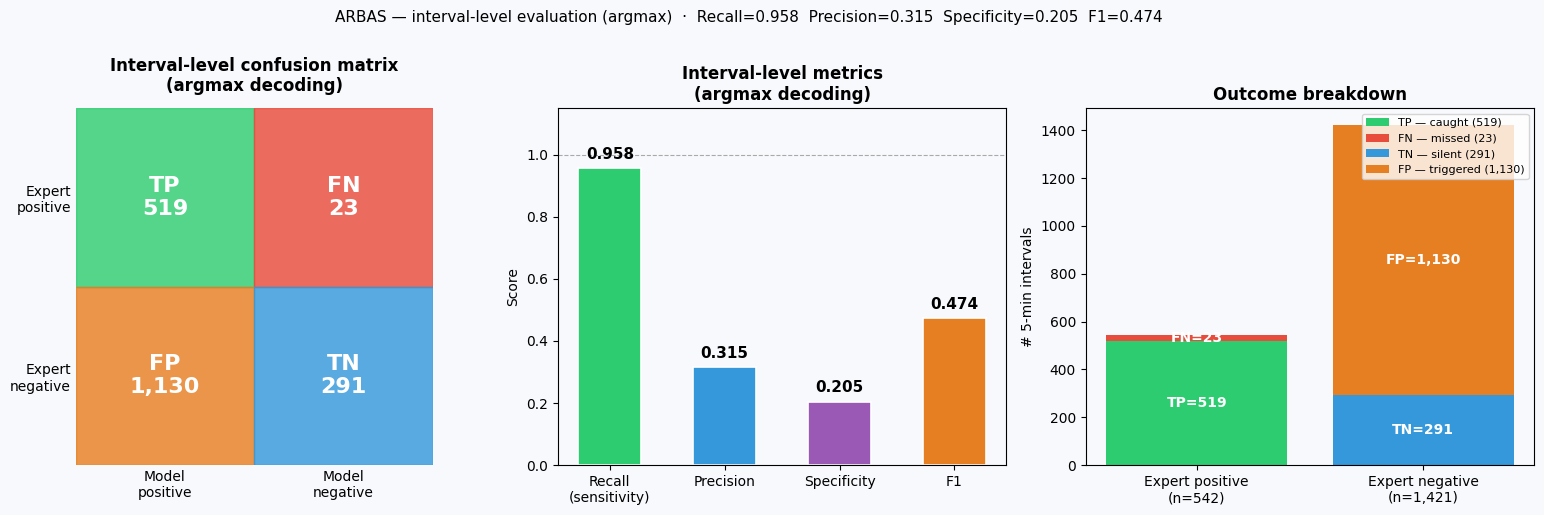

In [9]:
# ── B. Headline confusion matrix ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#f7f9fc')

# ── (1) Confusion matrix tile ─────────────────────────────────────────────────
ax = axes[0]
labels = [['TP', 'FN'], ['FP', 'TN']]
counts = [[TP, FN], [FP, TN]]
colors = [['#2ecc71', '#e74c3c'], ['#e67e22', '#3498db']]
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_aspect('equal')
for r in range(2):
    for c in range(2):
        ax.add_patch(plt.Rectangle([c, 1-r], 1, 1, color=colors[r][c], alpha=0.82))
        ax.text(c+0.5, 1.5-r, f"{labels[r][c]}\n{counts[r][c]:,}",
                ha='center', va='center', fontsize=16, fontweight='bold', color='white')
ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(['Model\npositive', 'Model\nnegative'], fontsize=10)
ax.set_yticklabels(['Expert\nnegative', 'Expert\npositive'], fontsize=10)
ax.set_title('Interval-level confusion matrix\n(argmax decoding)', fontsize=12, fontweight='bold', pad=12)
ax.tick_params(length=0)
for spine in ax.spines.values(): spine.set_visible(False)

# ── (2) Metric bars ───────────────────────────────────────────────────────────
ax = axes[1]
metrics = {'Recall\n(sensitivity)': recall, 'Precision': precision,
           'Specificity': specificity, 'F1': f1}
mc = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22']
bars = ax.bar(list(metrics), list(metrics.values()), color=mc,
              edgecolor='white', linewidth=1.2, width=0.55)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=10)
ax.set_title('Interval-level metrics\n(argmax decoding)', fontsize=12, fontweight='bold')
ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
for bar, val in zip(bars, metrics.values()):
    lbl = f'{val:.3f}' if not np.isnan(val) else 'n/a'
    ax.text(bar.get_x()+bar.get_width()/2, (val if not np.isnan(val) else 0)+0.02,
            lbl, ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_facecolor('#f7f9fc')

# ── (3) Stacked outcome bars ──────────────────────────────────────────────────
ax = axes[2]
pos_lbl = f'Expert positive\n(n={TP+FN:,})'
neg_lbl = f'Expert negative\n(n={TN+FP:,})'
ax.bar([pos_lbl], [TP],  color='#2ecc71', label=f'TP — caught ({TP:,})')
ax.bar([pos_lbl], [FN],  bottom=[TP], color='#e74c3c', label=f'FN — missed ({FN:,})')
ax.bar([neg_lbl], [TN],  color='#3498db', label=f'TN — silent ({TN:,})')
ax.bar([neg_lbl], [FP],  bottom=[TN], color='#e67e22', label=f'FP — triggered ({FP:,})')
for xpos, bot, val, lbl in [(0, TP/2, TP, f'TP={TP:,}'), (0, TP+FN/2, FN, f'FN={FN:,}'),
                             (1, TN/2, TN, f'TN={TN:,}'), (1, TN+FP/2, FP, f'FP={FP:,}')]:
    if val > 0:
        ax.text(xpos, bot, lbl, ha='center', va='center', color='white', fontweight='bold')
ax.set_ylabel('# 5-min intervals', fontsize=10)
ax.set_title('Outcome breakdown', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.set_facecolor('#f7f9fc')

plt.suptitle(f'ARBAS — interval-level evaluation (argmax)  ·  '
             f'Recall={recall:.3f}  Precision={precision:.3f}  Specificity={specificity:.3f}  F1={f1:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


Strategy comparison (interval level):
 strategy  TP  FN   FP  TN  recall  precision  specificity    F1
   argmax 519  23 1130 291   0.958      0.315        0.205 0.474
      vec 540   2 1250 171   0.996      0.302        0.120 0.463
       pr 274 268  806 615   0.506      0.254        0.433 0.338
consensus 519  23 1130 291   0.958      0.315        0.205 0.474


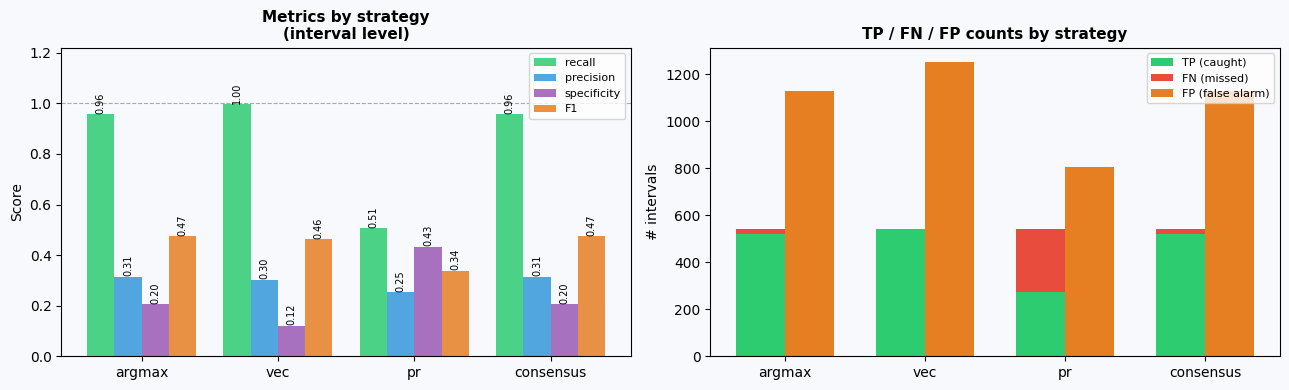

In [10]:
# ── C. Strategy comparison ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

strat_rows = []
for s, col in [('argmax','model_pos_argmax'), ('vec','model_pos_vec'),
               ('pr','model_pos_pr'), ('consensus','model_positive')]:
    tp_s = int((ivl['exp_positive'] & ivl[col]).sum())
    fn_s = int((ivl['exp_positive'] & ~ivl[col]).sum())
    fp_s = int((~ivl['exp_positive'] & ivl[col]).sum())
    tn_s = int((~ivl['exp_positive'] & ~ivl[col]).sum())
    rc = tp_s/(tp_s+fn_s) if (tp_s+fn_s) else float('nan')
    pr = tp_s/(tp_s+fp_s) if (tp_s+fp_s) else float('nan')
    sp = tn_s/(tn_s+fp_s) if (tn_s+fp_s) else float('nan')
    f1_s = 2*pr*rc/(pr+rc) if (pr and rc) else float('nan')
    strat_rows.append({'strategy': s, 'TP': tp_s, 'FN': fn_s, 'FP': fp_s, 'TN': tn_s,
                       'recall': rc, 'precision': pr, 'specificity': sp, 'F1': f1_s})

strat_df = pd.DataFrame(strat_rows)
print("Strategy comparison (interval level):")
print(strat_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#f7f9fc')
x = np.arange(len(strat_df)); w = 0.2

ax = axes[0]
for i, (metric, color) in enumerate([('recall','#2ecc71'),('precision','#3498db'),
                                       ('specificity','#9b59b6'),('F1','#e67e22')]):
    bars = ax.bar(x + i*w, strat_df[metric].fillna(0), w, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, strat_df[metric]):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.2f}',
                    ha='center', fontsize=7, rotation=90)
ax.set_xticks(x + w*1.5); ax.set_xticklabels(strat_df['strategy'], fontsize=10)
ax.set_ylim(0, 1.22); ax.set_ylabel('Score', fontsize=10)
ax.set_title('Metrics by strategy\n(interval level)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
ax.set_facecolor('#f7f9fc')

ax = axes[1]
w2 = 0.35
ax.bar(x - w2/2, strat_df['TP'], w2, label='TP (caught)', color='#2ecc71')
ax.bar(x - w2/2, strat_df['FN'], w2, bottom=strat_df['TP'], label='FN (missed)', color='#e74c3c')
ax.bar(x + w2/2, strat_df['FP'], w2, label='FP (false alarm)', color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(strat_df['strategy'], fontsize=10)
ax.set_ylabel('# intervals', fontsize=10)
ax.set_title('TP / FN / FP counts by strategy', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.set_facecolor('#f7f9fc')

plt.tight_layout(); plt.show()


## D. Per-species breakdown

Expert annotated **multiple species** here (unlike Harrapatu which only labelled Tt).  
For each shared species we compare:
- How many intervals the expert assigned as top-species
- How many intervals the model fired that label (any segment, majority label)
- Per-species recall (any-segment: lenient; majority: strict)


Per-species interval-level breakdown:
         species  exp_intervals  model_maj  model_any  overlap_any  overlap_maj  only_expert  only_model_maj  recall_any  recall_maj
Dc (expert-only)            542          0          0            0            0          542               0       0.000       0.000
Lo (expert-only)            535          0          0            0            0          535               0       0.000       0.000
              Gg            441          4          4            1            1          440               3       0.002       0.002
              Tt             75         41         59            3            1           72              40       0.040       0.013
              Sc              7          0          0            0            0            7               0       0.000       0.000
              Dd              2          0          4            0            0            2               0       0.000       0.000
              Pm              0

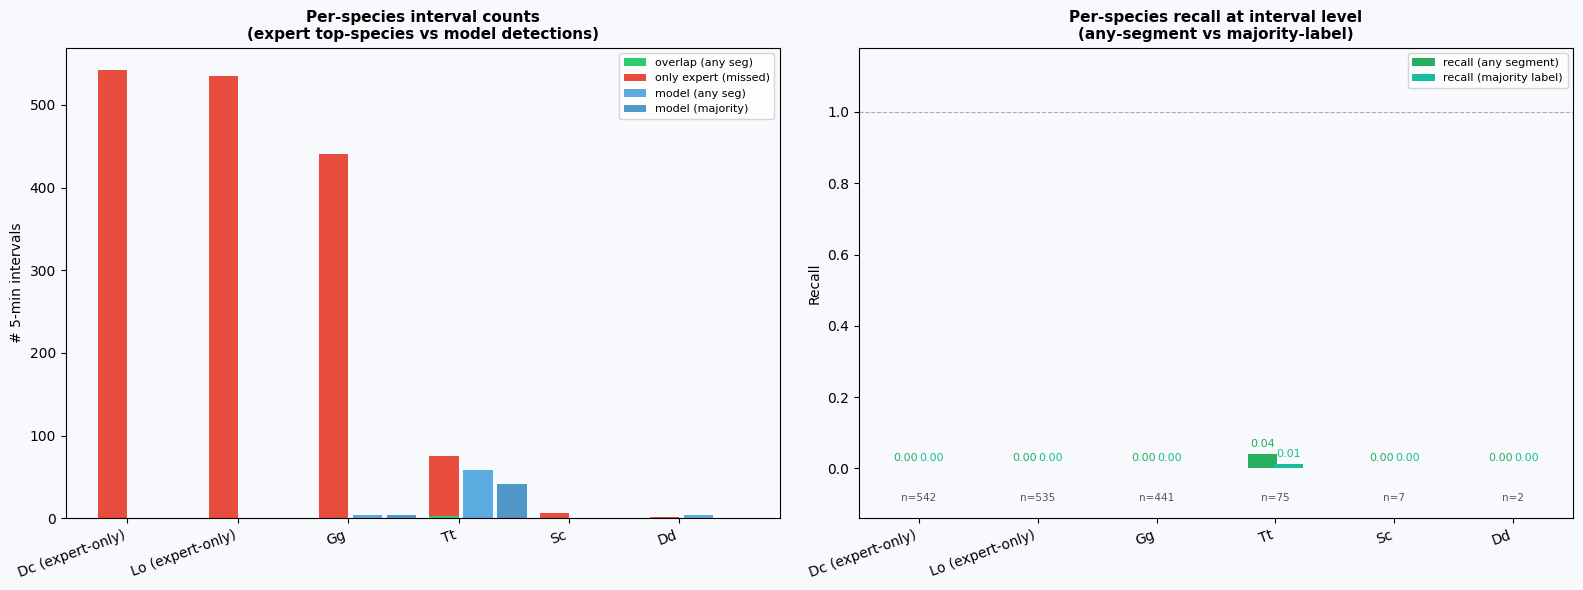

In [11]:
# ── D. Per-species breakdown ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

SHARED_SPECIES = ['Dd', 'Gg', 'Gm', 'Oo', 'Pm', 'Sc', 'Tt', 'Ambig']
# Expert-only species (Bb, Dc, Lo, Zc) not in model vocab → count as FN if they appear

rows = []
for sp in SHARED_SPECIES:
    exp_set = set(ivl.loc[ivl['exp_top_species'] == sp, 'interval'])
    maj_set = set(ivl.loc[ivl['model_sp_majority'] == sp, 'interval'])
    pat = r'(?:^|, )' + sp + r'(?:,|$)'
    any_set = set(ivl.loc[ivl['model_sp_any'].str.contains(pat, regex=True, na=False), 'interval'])

    both_any = len(exp_set & any_set)
    both_maj = len(exp_set & maj_set)
    only_exp = len(exp_set - any_set)
    only_mod = len(maj_set - exp_set)

    rows.append({
        'species':        sp,
        'exp_intervals':  len(exp_set),
        'model_maj':      len(maj_set),
        'model_any':      len(any_set),
        'overlap_any':    both_any,
        'overlap_maj':    both_maj,
        'only_expert':    only_exp,
        'only_model_maj': only_mod,
        'recall_any':     round(both_any / len(exp_set), 3) if exp_set else float('nan'),
        'recall_maj':     round(both_maj / len(exp_set), 3) if exp_set else float('nan'),
    })

# Expert-only species (model can't predict them → always FN)
exp_only_sp = ['Bb', 'Dc', 'Lo', 'Zc']
for sp in exp_only_sp:
    col = f'sum_exp_{sp}'
    if col in ivl.columns:
        n = int((ivl[col] > 0).sum())
        if n > 0:
            rows.append({'species': sp + ' (expert-only)', 'exp_intervals': n,
                         'model_maj': 0, 'model_any': 0,
                         'overlap_any': 0, 'overlap_maj': 0,
                         'only_expert': n, 'only_model_maj': 0,
                         'recall_any': 0.0, 'recall_maj': 0.0})

sp_df = pd.DataFrame(rows).sort_values('exp_intervals', ascending=False)
print("Per-species interval-level breakdown:")
print(sp_df.to_string(index=False))

sp_plot = sp_df[sp_df['exp_intervals'] > 0].copy()
sp_names = sp_plot['species'].tolist()
x = np.arange(len(sp_names)); w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f7f9fc')

ax = axes[0]
ax.bar(x,           sp_plot['overlap_any'],   w*1.2, label='overlap (any seg)',    color='#2ecc71')
ax.bar(x,           sp_plot['only_expert'],   w*1.2, bottom=sp_plot['overlap_any'],
       label='only expert (missed)', color='#e74c3c')
ax.bar(x + w*1.4,   sp_plot['model_any'],     w*1.2, label='model (any seg)',      color='#3498db', alpha=0.8)
ax.bar(x + w*1.4*2, sp_plot['model_maj'],     w*1.2, label='model (majority)',     color='#2980b9', alpha=0.8)
ax.set_xticks(x + w*0.6); ax.set_xticklabels(sp_names, rotation=20, ha='right')
ax.set_ylabel('# 5-min intervals', fontsize=10)
ax.set_title('Per-species interval counts\n(expert top-species vs model detections)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.set_facecolor('#f7f9fc')

ax = axes[1]
rc_any = sp_plot['recall_any'].fillna(0)
rc_maj = sp_plot['recall_maj'].fillna(0)
ax.bar(x - w/2, rc_any, w*1.1, label='recall (any segment)',   color='#27ae60')
ax.bar(x + w/2, rc_maj, w*1.1, label='recall (majority label)',color='#1abc9c')
for i, (ra, rm, n) in enumerate(zip(rc_any, rc_maj, sp_plot['exp_intervals'])):
    ax.text(i - w/2, ra + 0.02, f'{ra:.2f}', ha='center', fontsize=8, color='#27ae60')
    ax.text(i + w/2, rm + 0.02, f'{rm:.2f}', ha='center', fontsize=8, color='#1abc9c')
    ax.text(i, -0.09, f'n={n}', ha='center', fontsize=7.5, color='#555')
ax.set_xticks(x); ax.set_xticklabels(sp_names, rotation=20, ha='right')
ax.set_ylim(-0.14, 1.18); ax.set_ylabel('Recall', fontsize=10)
ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
ax.set_title('Per-species recall at interval level\n(any-segment vs majority-label)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_facecolor('#f7f9fc')

plt.tight_layout(); plt.show()


In [12]:
# ── E. FP / FN deep dive ──────────────────────────────────────────────────────
fp_ivl = ivl[ivl['outcome'] == 'FP'].copy()
fn_ivl = ivl[ivl['outcome'] == 'FN'].copy()

print(f"False positives : {len(fp_ivl):,} expert-negative intervals the model triggered on")
print(f"False negatives : {len(fn_ivl):,} expert-positive intervals the model missed entirely")

def explode_sp_any(subset):
    sp = subset['model_sp_any'].str.split(', ').explode()
    return sp[sp.str.strip() != ''].value_counts()

print("\nSpecies fired in FP intervals (model fired, expert found nothing):")
fp_sp = explode_sp_any(fp_ivl)
print(fp_sp.to_string() if len(fp_sp) else '  (none)')

print("\nExpert top-species in FN intervals (model missed entirely):")
print(fn_ivl['exp_top_species'].value_counts().to_string())

print(f"\nFP — cetacean segments per interval (how many segs drove the false alarm):")
print(fp_ivl['n_cetacean_segs'].describe().round(2).to_string())

print(f"\nFN — uncertain segments in missed intervals (strategies partly disagreed):")
print(fn_ivl['n_uncertain_segs'].describe().round(2).to_string())
fn_with_unc = (fn_ivl['n_uncertain_segs'] > 0).sum()
print(f"  FN intervals with ≥1 uncertain seg: {fn_with_unc:,} of {len(fn_ivl):,}")
print("  → borderline misses where strategies partially disagreed")


False positives : 1,130 expert-negative intervals the model triggered on
False negatives : 23 expert-positive intervals the model missed entirely

Species fired in FP intervals (model fired, expert found nothing):
model_sp_any
Ambig    765
Oo        33
Bp         8
Gg         3
Tt         1

Expert top-species in FN intervals (model missed entirely):
exp_top_species
Gg    18
Tt     3
Dc     1
Sc     1

FP — cetacean segments per interval (how many segs drove the false alarm):
count    1130.00
mean       14.43
std        16.75
min         0.00
25%         0.00
50%         7.00
75%        25.00
max        60.00

FN — uncertain segments in missed intervals (strategies partly disagreed):
count    23.00
mean      5.17
std       5.15
min       0.00
25%       1.50
50%       3.00
75%       8.00
max      18.00
  FN intervals with ≥1 uncertain seg: 22 of 23
  → borderline misses where strategies partially disagreed


In [13]:
# ── F. Uncertain-segment audit in FN intervals ────────────────────────────────
fn_intervals = set(fn_ivl['interval'])
fn_segs = df_mine[
    df_mine['interval'].isin(fn_intervals) &
    (df_mine['pred_consensus'] == 'uncertain')
].copy()

fn_segs['pattern'] = (
    fn_segs['pred_argmax'] + ' / ' +
    fn_segs['pred_vec']    + ' / ' +
    fn_segs['pred_pr']
)

print(f"Uncertain segments inside FN intervals: {len(fn_segs):,}")
print()
print("Top disagreement patterns (argmax / vec / pr):")
print(fn_segs['pattern'].value_counts().head(15).to_string())


Uncertain segments inside FN intervals: 119

Top disagreement patterns (argmax / vec / pr):
pattern
background / Physeter_macrocephalus / background        64
background / Stenella_coeruleoalba / background         16
background / Orcinus_orca / background                  16
background / Delphinidae_unknown / background           12
background / Balaenoptera_acutorostrata / background    11
